# Inference Notebook
Used to mask a random image from the dataset and try to reconstruct it with weights of the training. 

In [5]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [6]:
import torch
import os
import glob
import random
import wandb
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
from safetensors import safe_open
from albumentations.pytorch import ToTensorV2
from local_datasets.terramesh import Transpose, MultimodalTransforms, MultimodalNormalize, statistics
from utils.utils import load_specs, build_urls
from utils.masking import generate_mask
from local_datasets.terramesh_dataset import TerraMeshDataset
from virtues.modules.multiplex_virtues import TerraMeshViT

/home/corentinS/.conda/envs/pds_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Paths
PATH_TO_WEIGHTS = "../experiments/final_train_tot_loss_eval/checkpoints/checkpoint-84780" # Path to the checkpoint to load for inference
PATH_DATASET = "../../../data/corentin/data/TerraMesh/val"
modalities =  ["S2L2A", "S1RTC"]
PATH_SENSORS_SPECS = './spectrum/pretraining_sensors.yaml' # Path to sensors specs file
PATH_SPECTRUM_SPECS = './spectrum/electromagnetic_spectrum.yaml' # Path to spectrum specs file

### 1. Dataset Initialization

In [8]:
# Load the sensor and spectrum specifications
sensors = [1, 2]  # Example sensor IDs

sensor_specs, spectrum_specs = load_specs(PATH_SENSORS_SPECS, PATH_SPECTRUM_SPECS)
# Filter the sensor and spectrum specs to only include the sensors specified in the config
sensor_specs = {k: v for k, v in sensor_specs.items() if v['sensor_idx'] in sensors}

# Build remap from old ids to contiguous [0..N-1]
selected_old_ids = sorted({v["sensor_idx"] for v in sensor_specs.values()})
old_to_new = {old_id: new_id for new_id, old_id in enumerate(selected_old_ids)}

# Apply remap in-place (or on a copied dict)
for k in sensor_specs:
    sensor_specs[k]["sensor_idx"] = old_to_new[sensor_specs[k]["sensor_idx"]]
num_sensors = len(sensors) 

In [9]:
val_transforms = MultimodalTransforms(
        transforms=A.Compose([
            Transpose([1, 2, 0]),  # Convert data to channel last (expected shape from albumentations)
            MultimodalNormalize(mean=statistics["mean"], std=statistics["std"]),
            A.CenterCrop(224, 224),
            ToTensorV2(),  # Convert to tensor and back to channel first
        ],
            is_check_shapes=False,  # Not needed because of aligned data in TerraMesh
            additional_targets={m: "image" for m in modalities}  
        ),
        non_image_modalities=["__key__", "__url__"],  # Additional non-image keys
    )


In [10]:
# Load the test dataset
all_shard_names = sorted([
    os.path.basename(s) 
    for s in glob.glob(os.path.join(PATH_DATASET, modalities[0], "*.tar"))
    if "majortom" in os.path.basename(s)  # ← only keep majortom shards
    ])
    
print(f"DEBUG: Searching for tar files at: {os.path.join(PATH_DATASET, modalities[0], '*.tar')}")
print(f"DEBUG: Found {len(all_shard_names)} majortom shards")
if all_shard_names:
    print(f"DEBUG: First 3 shards: {all_shard_names[:3]}")
else:
    # Try to see what files actually exist
    all_files = glob.glob(os.path.join(PATH_DATASET, modalities[0], "*.tar"))
    print(f"DEBUG: All tar files found: {all_files}")
    print(f"DEBUG: Dataset path: {PATH_DATASET}")
    print(f"DEBUG: First modality: {modalities[0]}")
    raise ValueError(f"No majortom tar files found at {os.path.join(PATH_DATASET, modalities[0])}")

random.shuffle(all_shard_names)

test_shard_names = all_shard_names[7:]
val_urls = build_urls(PATH_DATASET, modalities, test_shard_names)

test_dataset = TerraMeshDataset(
    #path=conf.dataset_path,
    urls=val_urls,
    modalities=modalities,
    sensor_specs=sensor_specs,
    spectrum_specs=spectrum_specs,
    shuffle=False,  # No shuffling for validation/test
    #split= "val",
    transform=val_transforms,
    seed=42,
    batch_size=8,
    patch_size=16,
    masking_ratio= (0.6, 0.8)
)


DEBUG: Searching for tar files at: ../../../data/corentin/data/TerraMesh/val/S2L2A/*.tar
DEBUG: Found 8 majortom shards
DEBUG: First 3 shards: ['majortom_shard_000001.tar', 'majortom_shard_000002.tar', 'majortom_shard_000003.tar']


### 2. Visualization
Vizualization of the original image using IRRG pseudo-coloring for Sentinel-2 L2A images and using a dB scale as VH-VV-VV/VH for Sentinel-1 RTC images.

In [13]:
b = random.randint(0, images.shape[0] - 1)
print(f"Visualizing sample {b} from the batch")

Visualizing sample 0 from the batch


In [14]:
# Get one batch
images, channel_indices, masks, sensor_indices, proj_indices = next(iter(test_dataset))
# images: [B, C, H, W]
# Pick a random item from the batch

img = images[b]  # [C, H, W]
mask = masks[b]  # [num_patches]
channel_idx = channel_indices[b]  # [C]
sensor_idx = sensor_indices[b]  # [C]
proj_idx = proj_indices[b]  # [C]

print("channel_idx range:", channel_idx.min().item(), channel_idx.max().item())
print("sensor_idx range:", sensor_idx.min().item(), sensor_idx.max().item())
print("proj_idx range:", proj_idx.min().item(), proj_idx.max().item())


# S2L2A has 12 bands (first channels), pick RGB = bands 3,2,1 (0-indexed)
rgb = img[[3, 2, 1]].permute(1, 2, 0).numpy()

# Normalize to [0,1] for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

# Sentinel-1 has 2 bands (VV, VH)
s1rtc = img[11:13] 

channel_idx range: 0 13
sensor_idx range: 0 1
proj_idx range: 0 16


In [15]:
# Utility for visualization (Sentinel-1 backscatter to dB and normalization)
def normalize_percentile(arr, low=2, high=98):
    vmin = np.nanpercentile(arr, low)
    vmax = np.nanpercentile(arr, high)
    return (np.clip(arr, vmin, vmax) - vmin) / (vmax - vmin)

In [16]:
# 1. Denormalize → back to original scale (likely linear or log)
mean = torch.tensor(statistics["mean"]["S1RTC"]).view(-1, 1, 1)
std  = torch.tensor(statistics["std"]["S1RTC"]).view(-1, 1, 1)
s1rtc_denorm = s1rtc * std + mean  # [C, H, W]

# 2. Light speckle filter
vh = s1rtc_denorm[1]
vv = s1rtc_denorm[0]

# 3. Ratio in log space (VH/VV)
#    Add small epsilon to avoid log(0)
ratio = vh - vv

# 4. Clip to typical SAR dB ranges before display
vv_display = np.clip(vv, -25, 0)
vh_display = np.clip(vh, -30, -5)
ratio_display = np.clip(ratio, -15, 5)

# 5. Normalize each to [0, 1] for imshow
def to_uint8(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

R = to_uint8(vh_display)
G = to_uint8(vv_display)
B = to_uint8(ratio_display)
s1_rgb = np.stack([R, G, B], axis=-1)

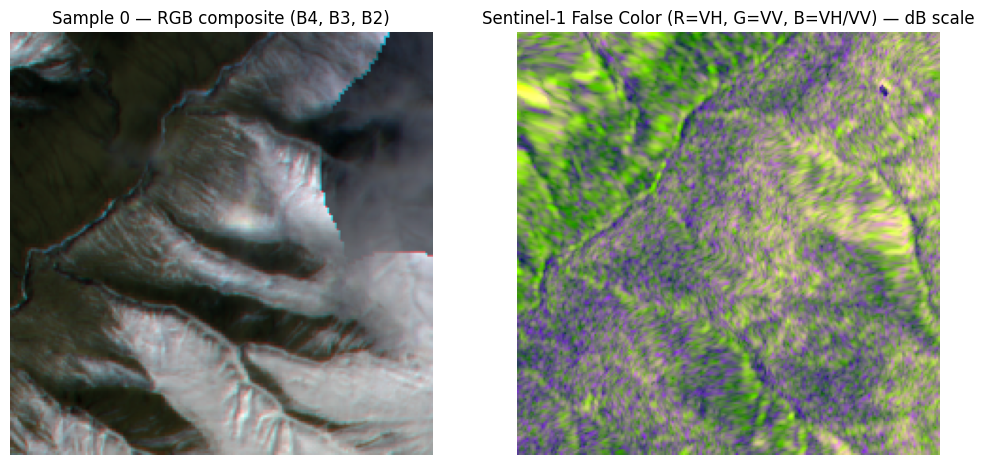

In [17]:
# Plot the two modalities side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(rgb)
axs[0].set_title(f"Sample {b} — RGB composite (B4, B3, B2)")
axs[0].axis("off")
axs[1].imshow(s1_rgb)
axs[1].set_title('Sentinel-1 False Color (R=VH, G=VV, B=VH/VV) — dB scale')
axs[1].axis("off")
plt.show()

### 3. Model Initialization
We load here the weights of the model with the different pretraining tested. 

In [18]:
conf = OmegaConf.load('./virtues/configs/base_config.yaml')


In [19]:
# Model initialization
model = TerraMeshViT(
        use_default_config = False,
        custom_config = None,
        spectrum_specs=spectrum_specs,
        num_sensors=num_sensors,
        prior_bias_embedding_type='wl',
        prior_bias_embedding_fusion_type='concatenate',
        patch_size=conf.model.patch_size,
        model_dim=conf.model.model_dim,
        feedforward_dim=conf.model.feedforward_dim,
        encoder_pattern=conf.model.encoder_pattern,
        num_encoder_heads=conf.model.num_encoder_heads,
        decoder_pattern=conf.model.decoder_pattern,
        num_decoder_heads=conf.model.num_decoder_heads,
        num_hidden_layers=conf.model.num_decoder_hidden_layers,
        positional_embedding_type=conf.model.positional_embedding_type,
        dropout=conf.model.dropout,
        group_layers=conf.model.group_layers,
        norm_after_encoder_decoder=conf.model.norm_after_encoder_decoder,
        verbose=False
    )

We provide the weights of the pretrained VirTues instance

In [ ]:
#1. Download from W&B
run = wandb.init(project="TerraMesh", job_type="eval")
artifact = run.use_artifact("final_train_tot_loss_eval:latest-run", type="model")
checkpoint_dir = artifact.download()

# 2. Load weights with safetensors
weights = {}
with safe_open(os.path.join(checkpoint_dir, 'model.safetensors'), framework="pt", device='cpu') as f:
    for k in f.keys():
        weights[k] = f.get_tensor(k)
model.load_state_dict(weights)

model = model.cuda()
model = model.eval()

In [20]:
# Load the checkpoint saved locally
weights = {}
with safe_open(os.path.join(PATH_TO_WEIGHTS, "model.safetensors"), framework="pt", device="cpu") as f:
    for k in f.keys():
        weights[k] = f.get_tensor(k)

model.load_state_dict(weights)
model = model.cuda().eval()

### 4. Reconstruction of a Partially Masked Image

We can reconstruct a masked image using a simple forward pass with VirTues. As a first step, we test reconstruction under independent partial masking applied to each channel. To generate these per-channel masks, you can use the helper function utils.masking.generate_mask.

In [21]:
# Prepare inputs for the model
# Move all to CUDA
img        = img.cuda()     # or however you batch
channel_idx = channel_idx.cuda().long()  # Ensure indices are long tensors
mask        = mask.cuda()
sensor_idx  = sensor_idx.cuda().long()
proj_idx    = proj_idx.cuda().long() 

# print shape and stats for debugging
print("Input shapes:")
print("img shape       :", img.shape)
print("channel_idx shape:", channel_idx.shape)
print("mask shape       :", mask.shape)
print("sensor_idx shape :", sensor_idx.shape)
print("proj_idx shape   :", proj_idx.shape)

Input shapes:
img shape       : torch.Size([13, 224, 224])
channel_idx shape: torch.Size([13])
mask shape       : torch.Size([13, 14, 14])
sensor_idx shape : torch.Size([13])
proj_idx shape   : torch.Size([13, 14, 14])


In [22]:
with torch.no_grad():
    with torch.amp.autocast(device_type='cuda'):
        output = model.forward(
            multiplex=[img],
            channel_ids=[channel_idx],
            multiplex_mask=[mask],
            sensor_ids=[sensor_idx],
            projection_indices=[proj_idx],
        )
recon = output.decoded_multiplex

In [23]:
'''# Upsample patch mask to pixel resolution
mask_pixel = mask.repeat_interleave(16, dim=-2).repeat_interleave(16, dim=-1)  # [C, H, W]

# Composite: original where visible, reconstruction where masked
recon_tensor = recon[0]  # [C, H, W]
img_full = img.clone()   # [C, H, W] — your original input (before masking)
visualized = torch.where(mask_pixel, recon_tensor, img_full)'''


'# Upsample patch mask to pixel resolution\nmask_pixel = mask.repeat_interleave(16, dim=-2).repeat_interleave(16, dim=-1)  # [C, H, W]\n\n# Composite: original where visible, reconstruction where masked\nrecon_tensor = recon[0]  # [C, H, W]\nimg_full = img.clone()   # [C, H, W] — your original input (before masking)\nvisualized = torch.where(mask_pixel, recon_tensor, img_full)'

Text(0.5, 1.0, 'Original Crop')

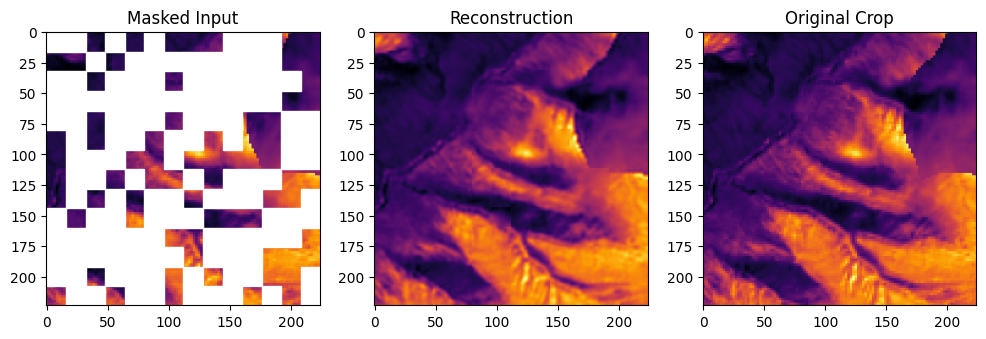

In [24]:
channel_idx_plot = 5

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(img[channel_idx_plot].cpu().numpy(), cmap='inferno')
for i in range(mask.shape[1]):
    for j in range(mask.shape[2]):
        if mask[channel_idx_plot,i,j]:
            ax[0].add_patch(plt.Rectangle((j*16, i*16), 16, 16, color='white'))
ax[0].set_title('Masked Input')

ax[1].imshow(recon[0][channel_idx_plot].cpu().numpy(), cmap='inferno')
ax[1].set_title('Reconstruction')
ax[2].imshow(img[channel_idx_plot].cpu().numpy(), cmap='inferno')
ax[2].set_title('Original Crop')

In [27]:
recon[0].shape


torch.Size([13, 224, 224])

In [29]:
img.shape

torch.Size([13, 224, 224])

In [32]:
sum((recon[0] - img)**2)

tensor([[2.3281, 0.9740, 0.5792,  ..., 0.2852, 0.1851, 0.4965],
        [1.2307, 1.9456, 0.9649,  ..., 0.2597, 0.5255, 0.5369],
        [0.5169, 1.3766, 0.9462,  ..., 0.7128, 0.3993, 0.4585],
        ...,
        [3.4799, 2.1844, 1.6292,  ..., 0.1966, 0.1041, 0.1194],
        [3.3219, 2.0265, 1.1287,  ..., 0.1063, 0.1261, 0.3880],
        [2.9445, 2.1798, 1.0150,  ..., 0.3759, 0.0669, 0.4408]],
       device='cuda:0')

### 5. Reconstruction of a Fully Masked Image

In [40]:
channel_idx_mask = 5
mask = torch.zeros_like(mask)
mask[channel_idx_mask] = True

In [41]:

with torch.amp.autocast(device_type='cuda'):
        output = model.forward(
            multiplex=[img],
            channel_ids=[channel_idx],
            multiplex_mask=[mask],
            sensor_ids=[sensor_idx],
            projection_indices=[proj_idx],
        )
recon = output.decoded_multiplex

Text(0.5, 1.0, 'Original Crop')

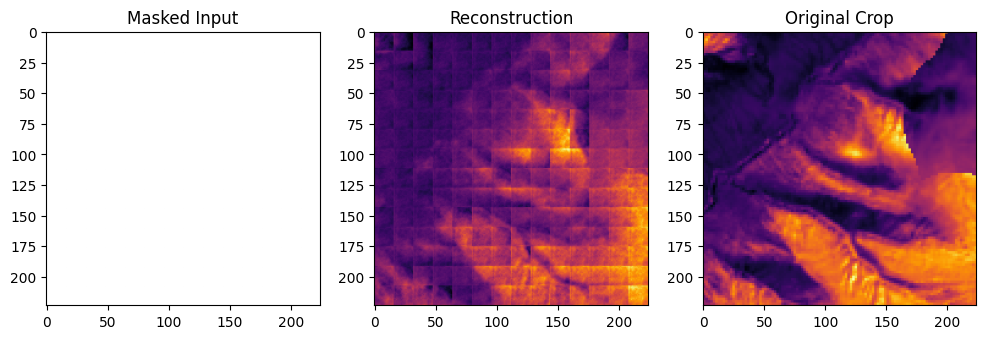

In [42]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(img[channel_idx_mask].cpu().numpy(), cmap='inferno')
for i in range(mask.shape[1]):
    for j in range(mask.shape[2]):
        if mask[channel_idx_mask,i,j]:
            ax[0].add_patch(plt.Rectangle((j*16, i*16), 16, 16, color='white'))
ax[0].set_title('Masked Input')

ax[1].imshow(recon[0][channel_idx_mask].detach().cpu().numpy(), cmap='inferno')
ax[1].set_title('Reconstruction')
ax[2].imshow(img[channel_idx_mask].cpu().numpy(), cmap='inferno')
ax[2].set_title('Original Crop')
